In [292]:
import pandas as pd

df = pd.read_csv('Bakery sales.csv')

In [293]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234005 entries, 0 to 234004
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     234005 non-null  int64  
 1   date           234005 non-null  object 
 2   time           234005 non-null  object 
 3   ticket_number  234005 non-null  float64
 4   article        234005 non-null  object 
 5   Quantity       234005 non-null  float64
 6   unit_price     234005 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 12.5+ MB


In [294]:
df.isnull().sum()

Unnamed: 0       0
date             0
time             0
ticket_number    0
article          0
Quantity         0
unit_price       0
dtype: int64

In [295]:
df.isna().sum()

Unnamed: 0       0
date             0
time             0
ticket_number    0
article          0
Quantity         0
unit_price       0
dtype: int64

In [296]:
from collections import Counter
all_products_buy = Counter(df['article'])

In [297]:
df.head()

,Unnamed: 0,date,time,ticket_number,article,Quantity,unit_price
0,0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,5,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,8,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [298]:
df = df.drop(['ticket_number'], axis=1)

In [299]:
df.head()

,Unnamed: 0,date,time,article,Quantity,unit_price
0,0,2021-01-02,08:38,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,5,2021-01-02,09:14,PAIN,1.0,"1,15 €"
4,8,2021-01-02,09:25,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [300]:
df = df.drop(['Unnamed: 0'],axis=1)

In [301]:
df.head()

,date,time,article,Quantity,unit_price
0,2021-01-02,08:38,BAGUETTE,1.0,"0,90 €"
1,2021-01-02,08:38,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,2021-01-02,09:14,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,2021-01-02,09:14,PAIN,1.0,"1,15 €"
4,2021-01-02,09:25,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [302]:
df['unit_price'] = df['unit_price'].str.replace(' €', '').str.replace(',', '.').astype(float)

In [303]:
import pandas as pd

# 1. Загрузка и базовая очистка
df = pd.read_csv('Bakery sales.csv')
df = df.drop(columns=['Unnamed: 0', 'ticket_number'], errors='ignore')

# Превращаем unit_price в число (убираем ' €' и меняем запятую на точку)
df['unit_price'] = df['unit_price'].str.replace(' €', '').str.replace(',', '.').astype(float)

# 2. Считаем общие продажи за день (чтобы знать, продалось ли всё в итоге)
daily_total = df.groupby(['date', 'article', 'unit_price'])['Quantity'].sum().reset_index(name='total_day_qty')

# 3. Считаем продажи до 15:00
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour
before_15 = df[df['hour'] < 15].groupby(['date', 'article'])['Quantity'].sum().reset_index(name='qty_before_15')

# 4. Соединяем данные
final_df = pd.merge(daily_total, before_15, on=['date', 'article'], how='left').fillna(0)

# 5. Добавляем логику склада (условно 1000 единиц в начале дня)
stock_initial = 1000
final_df['stock_remaining_after_15'] = stock_initial - final_df['qty_before_15']

# 6. ВЫСТАВЛЯЕМ МЕТКУ (Target)
# Логика: если продажи до 15:00 составляют 100% от дневных продаж, 
# значит после 15:00 товара либо не было, либо его не покупали.
final_df['will_sell_out'] = (
    (final_df['total_day_qty'] - (final_df['qty_before_15'] * 1.02)) <= 0
).astype(int)
# Оставляем нужные колонки
result_table = final_df[['date', 'article', 'qty_before_15', 'stock_remaining_after_15', 'unit_price', 'will_sell_out']]

print(result_table.head(10))

         date          article  qty_before_15  stock_remaining_after_15  \
0  2021-01-02         BAGUETTE           46.0                     954.0   
1  2021-01-02          BANETTE           40.0                     960.0   
2  2021-01-02        BANETTINE            6.0                     994.0   
3  2021-01-02       BOULE 200G            6.0                     994.0   
4  2021-01-02       BOULE 400G           11.0                     989.0   
5  2021-01-02      BOULE POLKA            2.0                     998.0   
6  2021-01-02          BRIOCHE            2.0                     998.0   
7  2021-01-02      CAFE OU EAU            6.0                     994.0   
8  2021-01-02         CAMPAGNE           10.0                     990.0   
9  2021-01-02  CEREAL BAGUETTE           19.0                     981.0   

   unit_price  will_sell_out  
0        0.90              1  
1        1.05              1  
2        0.60              1  
3        1.10              1  
4        1.50      

In [304]:
result_table.head()

,date,article,qty_before_15,stock_remaining_after_15,unit_price,will_sell_out
0,2021-01-02,BAGUETTE,46.0,954.0,0.90,1
1,2021-01-02,BANETTE,40.0,960.0,1.05,1
2,2021-01-02,BANETTINE,6.0,994.0,0.60,1
3,2021-01-02,BOULE 200G,6.0,994.0,1.10,1
4,2021-01-02,BOULE 400G,11.0,989.0,1.50,1


In [305]:
import holidays

final_df['day_of_week'] = pd.to_datetime(final_df['date']).dt.dayofweek

final_df['month'] = pd.to_datetime(final_df['date']).dt.month

fr_holidays = holidays.France()
final_df['is_holiday'] = final_df['date'].apply(lambda x: 1 if x in fr_holidays else 0)

final_df.head()

,date,article,unit_price,total_day_qty,qty_before_15,stock_remaining_after_15,will_sell_out,day_of_week,month,is_holiday
0,2021-01-02,BAGUETTE,0.90,46.0,46.0,954.0,1,5,1,0
1,2021-01-02,BANETTE,1.05,40.0,40.0,960.0,1,5,1,0
2,2021-01-02,BANETTINE,0.60,6.0,6.0,994.0,1,5,1,0
3,2021-01-02,BOULE 200G,1.10,6.0,6.0,994.0,1,5,1,0
4,2021-01-02,BOULE 400G,1.50,11.0,11.0,989.0,1,5,1,0


In [306]:
final_df['stock_remaining_after_15'] = (100 - final_df['qty_before_15']).clip(lower=0)

# 3. Применяем твою метку (учитываем 10% запас от продаж до 15:00)
final_df['will_sell_out'] = (
    (final_df['total_day_qty'] - (final_df['qty_before_15'] * 1.1)) <= 0
).astype(int)

In [307]:
final_df

,date,article,unit_price,total_day_qty,qty_before_15,stock_remaining_after_15,will_sell_out,day_of_week,month,is_holiday
0,2021-01-02,BAGUETTE,0.90,46.0,46.0,54.0,1,5,1,0
1,2021-01-02,BANETTE,1.05,40.0,40.0,60.0,1,5,1,0
2,2021-01-02,BANETTINE,0.60,6.0,6.0,94.0,1,5,1,0
3,2021-01-02,BOULE 200G,1.10,6.0,6.0,94.0,1,5,1,0
4,2021-01-02,BOULE 400G,1.50,11.0,11.0,89.0,1,5,1,0
...,...,...,...,...,...,...,...,...,...,...
30254,2022-09-30,SPECIAL BREAD KG,5.20,1.0,1.0,99.0,1,4,9,0
30255,2022-09-30,SUCETTE,0.30,1.0,0.0,100.0,0,4,9,0
30256,2022-09-30,TARTELETTE,2.20,3.0,3.0,97.0,1,4,9,0
30257,2022-09-30,TRADITIONAL BAGUETTE,1.30,141.0,102.0,0.0,0,4,9,0


In [308]:
final_df['will_sell_out'].value_counts()

will_sell_out
1    20104
0    10155
Name: count, dtype: int64

In [309]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X = final_df.drop(['will_sell_out','date','total_day_qty'], axis=1)
y = final_df['will_sell_out']

In [310]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [311]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

# 1. Убедимся, что в X_train есть колонка 'article' (названия товаров)
# 2. Определяем список категориальных признаков
cat_cols = ['article'] 

def objective(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "auto_class_weights": "Balanced",
        "verbose": False,
        "random_state": 42,
        # ПЕРЕДАЕМ КАТЕГОРИИ СЮДА:
        "cat_features": cat_cols 
    }
    
    # Теперь модель будет знать, что 'article' — это текст, а не число
    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# Запуск
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Лучшие параметры найдены:", study.best_params)

[I 2026-03-04 09:54:51,591] A new study created in memory with name: no-name-81b6eae3-cd08-4e63-915d-302c0fda0a45
[I 2026-03-04 09:54:57,430] Trial 0 finished with value: 0.8087995654535578 and parameters: {'iterations': 700, 'depth': 8, 'learning_rate': 0.012969315199588024, 'l2_leaf_reg': 9.364546500427464}. Best is trial 0 with value: 0.8087995654535578.
[I 2026-03-04 09:55:06,613] Trial 1 finished with value: 0.8207033842070338 and parameters: {'iterations': 544, 'depth': 10, 'learning_rate': 0.05663492485835065, 'l2_leaf_reg': 4.354361734606703}. Best is trial 1 with value: 0.8207033842070338.
[I 2026-03-04 09:55:10,300] Trial 2 finished with value: 0.8145847400405132 and parameters: {'iterations': 678, 'depth': 6, 'learning_rate': 0.025914333265811863, 'l2_leaf_reg': 2.7283645704424093}. Best is trial 1 with value: 0.8207033842070338.
[I 2026-03-04 09:55:15,490] Trial 3 finished with value: 0.8201554543017958 and parameters: {'iterations': 438, 'depth': 9, 'learning_rate': 0.0374

Лучшие параметры найдены: {'iterations': 797, 'depth': 7, 'learning_rate': 0.11126940391089563, 'l2_leaf_reg': 6.050974393423876}


In [312]:
study.best_params.update({
    "verbose": False,
    "auto_class_weights": "Balanced",
    "random_state": 42,
    "cat_features": ['article'] # Указываем текстовую колонку
})

In [ ]:
final_model = CatBoostClassifier(**study.best_params, cat_features=['article'],      # Явно указываем текстовую колонку здесь
    auto_class_weights='Balanced', # Чтобы подтянуть точность редких случаев
    verbose=False,
    random_state=42)
final_model.fit(X_train, y_train)

CatBoostClassifier(cat_features=['article'], depth=7, iterations=797, l2_leaf_reg=6.050974393423876, learning_rate=0.11126940391089563, random_state=42, verbose=False)

--- ИТОГОВЫЙ ОТЧЕТ МОДЕЛИ ---
              precision    recall  f1-score   support

           0       0.74      0.63      0.68      2044
           1       0.82      0.89      0.85      4008

    accuracy                           0.80      6052
   macro avg       0.78      0.76      0.77      6052
weighted avg       0.79      0.80      0.79      6052



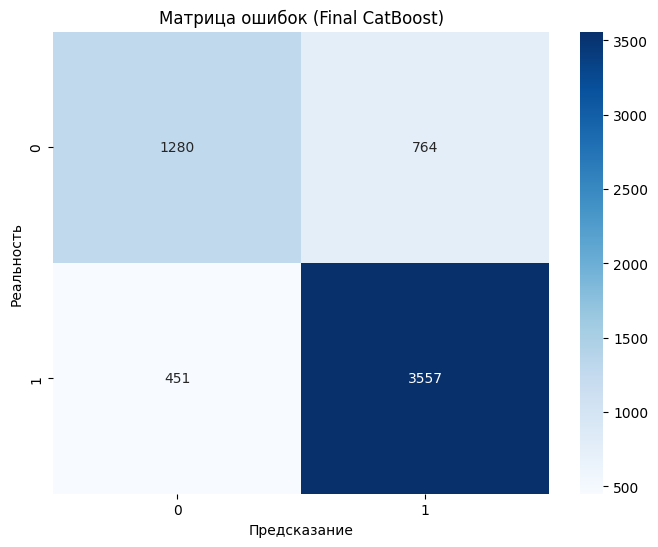

In [316]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
final_preds = final_model.predict(X_test)

# 4. ВЫВОДИМ РЕЗУЛЬТАТЫ
print("--- ИТОГОВЫЙ ОТЧЕТ МОДЕЛИ ---")
print(classification_report(y_test, final_preds))

# 5. Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (Final CatBoost)')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.show()

<Axes: >

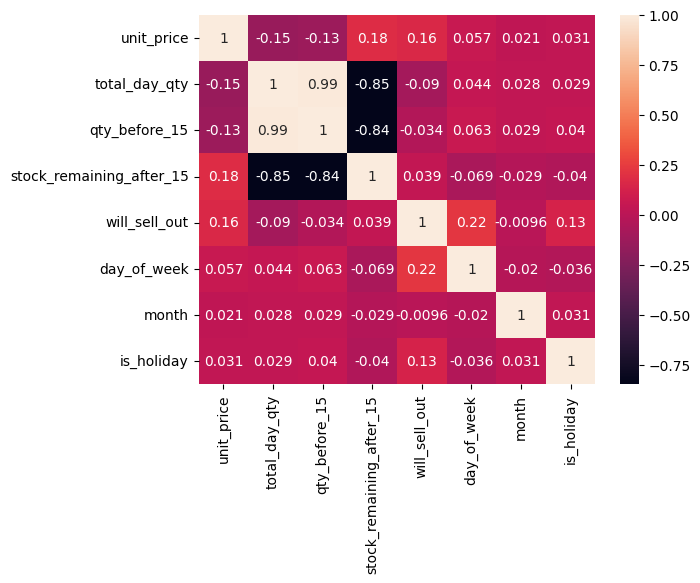

In [324]:
sns.heatmap(final_df.corr(numeric_only=True),annot=True)